In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import pandas as pd
from IPython.display import display
import scipy.integrate as spi

In [2]:
# Определяем переменные
x = sp.Symbol('x', real=True)
a, b = 0.566, -0.292

# Оригинальная функция
f = lambda x: np.exp(a * x**3 + b * x)

# Выражения Тейлора
T2 = 1 + b*x + (b**2/2)*x**2
T4 = 1 + b*x + (b**2/2)*x**2 + ((b**3 + 6*a)/6)*x**3 + ((b**4 + 24*a*b)/24)*x**4

# Функции для вычисления численных значений
T2 = sp.lambdify(x, T2, 'numpy')
T4 = sp.lambdify(x, T4, 'numpy')

# Функция интерполяционного многочлена P2(x)
def P2(x):
    term1 = np.exp(-a - b) * (x * (x - 1)) / 2
    term2 = (1 - x**2)
    term3 = np.exp(a + b) * (x * (x + 1)) / 2
    return term1 + term2 + term3

# Функция интерполяционного многочлена P4(x)
def P4(x):
    term1 = (2/3) * x * (x - 1) * (x - 0.5) * (x + 0.5) * np.exp(-a - b)
    term2 = (-8/3) * x * (x - 1) * (x - 0.5) * (x + 1) * np.exp(-a/8 - b/2)
    term3 = (-8/3) * x * (x - 1) * (x + 0.5) * (x + 1) * np.exp(a/8 + b/2)
    term4 = (2/3) * x * (x - 0.5) * (x + 0.5) * (x + 1) * np.exp(a + b)
    term5 = 4 * (x - 1) * (x - 0.5) * (x + 0.5) * (x + 1)
    return term1 + term2 + term3 + term4 + term5

# Инициализируем значения аргумента, вычисляем значения функции и её приближений
x_vals = np.arange(-1, 1.01, 0.01)
f_vals = f(x_vals)

T2_vals = T2(x_vals)
T4_vals = T4(x_vals)

P2_vals = P2(x_vals)
P4_vals = P4(x_vals)

err_T2 = np.abs(f_vals - T2_vals)
err_T4 = np.abs(f_vals - T4_vals)

err_P2 = np.abs(f_vals - P2_vals)
err_P4 = np.abs(f_vals - P4_vals)

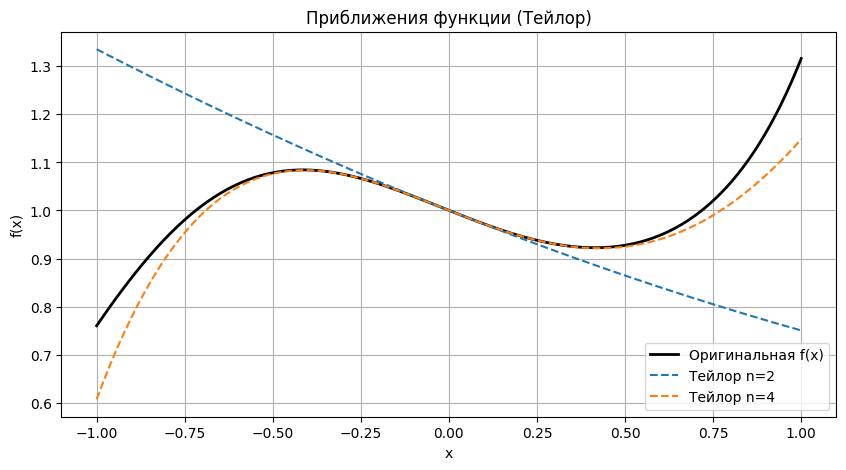

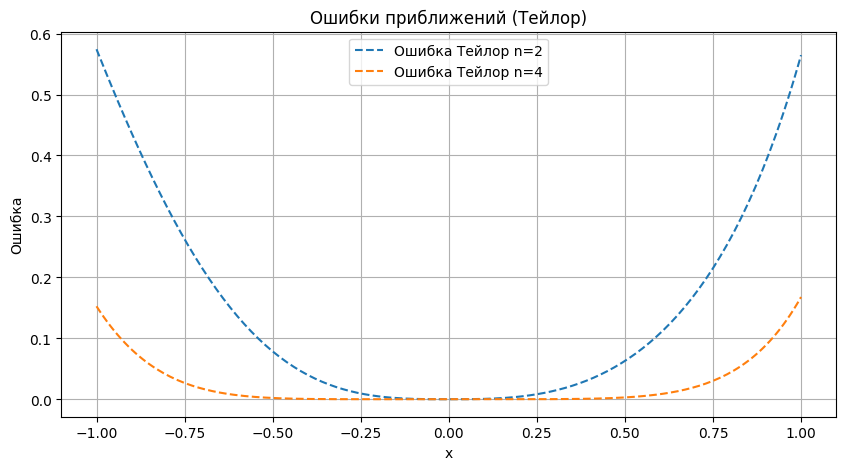

,x,f(x),T2(x),T4(x),Err T2,Err T4
0,-1.00,0.760332,1.334632,0.607812,0.574300,0.152520
1,-0.99,0.770967,1.330864,0.627232,0.559896,0.143735
2,-0.98,0.781489,1.327104,0.646132,0.545615,0.135356
3,-0.97,0.791890,1.323352,0.664521,0.531463,0.127369
4,-0.96,0.802165,1.319610,0.682404,0.517444,0.119761
...,...,...,...,...,...,...
196,0.96,1.246626,0.758970,1.115943,0.487656,0.130683
197,0.97,1.262802,0.756872,1.123612,0.505929,0.139190
198,0.98,1.279609,0.754784,1.131431,0.524825,0.148178
199,0.99,1.297072,0.752704,1.139398,0.544368,0.157674


In [3]:
# График приближений Тейлора
plt.figure(figsize=(10, 5))
plt.plot(x_vals, f_vals, label="Оригинальная f(x)", linewidth=2, color='black')
plt.plot(x_vals, T2_vals, label="Тейлор n=2", linestyle='dashed')
plt.plot(x_vals, T4_vals, label="Тейлор n=4", linestyle='dashed')
plt.legend()
plt.title("Приближения функции (Тейлор)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()
#График отклонений
plt.figure(figsize=(10, 5))
plt.plot(x_vals, err_T2, label="Ошибка Тейлор n=2", linestyle='dashed')
plt.plot(x_vals, err_T4, label="Ошибка Тейлор n=4", linestyle='dashed')
plt.legend()
plt.title("Ошибки приближений (Тейлор)")
plt.xlabel("x")
plt.ylabel("Ошибка")
plt.grid()
plt.show()

df_taylor = pd.DataFrame({
    "x": x_vals,
    "f(x)": f_vals,
    "T2(x)": T2_vals,
    "T4(x)": T4_vals,
    "Err T2": err_T2,
    "Err T4": err_T4
})

display(df_taylor)

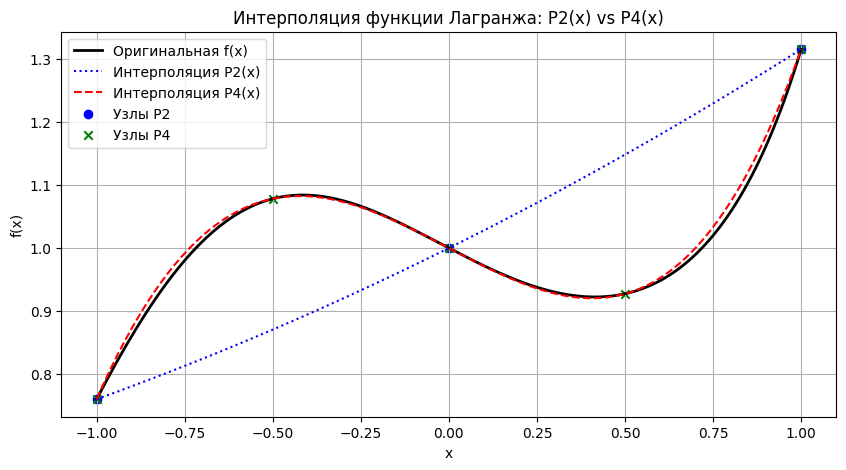

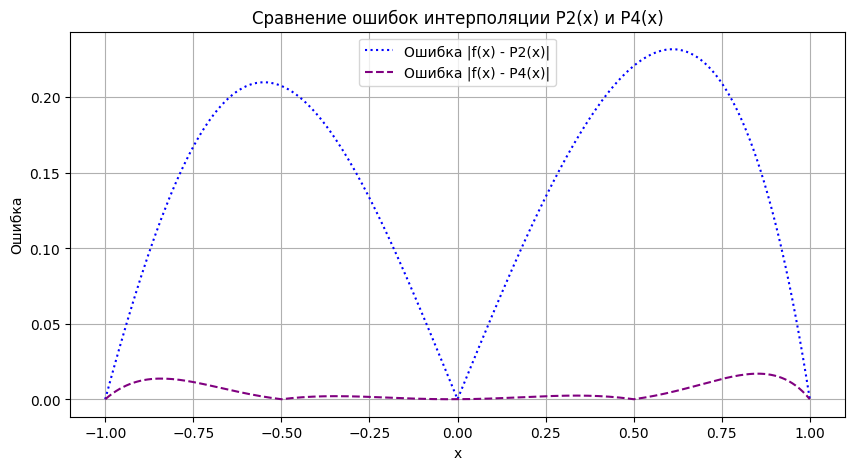

,x,f(x),P2(x),P4(x),Err P2,Err P4
0,-1.00,0.760332,0.760332,0.760332,0.000000e+00,0.000000e+00
1,-0.99,0.770967,0.762355,0.772912,8.612568e-03,1.944670e-03
2,-0.98,0.781489,0.764385,0.785195,1.710356e-02,3.706289e-03
3,-0.97,0.791890,0.766423,0.797183,2.546699e-02,5.293438e-03
4,-0.96,0.802165,0.768468,0.808880,3.369701e-02,6.714556e-03
...,...,...,...,...,...,...
196,0.96,1.246626,1.301156,1.255649,5.452987e-02,9.023377e-03
197,0.97,1.262802,1.304659,1.269978,4.185733e-02,7.175788e-03
198,0.98,1.279609,1.308170,1.284678,2.856101e-02,5.069358e-03
199,0.99,1.297072,1.311689,1.299756,1.461693e-02,2.684380e-03


In [4]:
# График f(x), P2(x) и P4(x)
plt.figure(figsize=(10, 5))
plt.plot(x_vals, f_vals, label="Оригинальная f(x)", linewidth=2, color='black')
plt.plot(x_vals, P2_vals, label="Интерполяция P2(x)", linestyle='dotted', color='blue')
plt.plot(x_vals, P4_vals, label="Интерполяция P4(x)", linestyle='dashed', color='red')
plt.scatter([-1, 0, 1], f(np.array([-1, 0, 1])), color='blue', marker='o', label="Узлы P2")
plt.scatter([-1, -0.5, 0, 0.5, 1], f(np.array([-1, -0.5, 0, 0.5, 1])), color='green', marker='x', label="Узлы P4")
plt.legend()
plt.title("Интерполяция функции Лагранжа: P2(x) vs P4(x)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()
#График отклонений
plt.figure(figsize=(10, 5))
plt.plot(x_vals, err_P2, label="Ошибка |f(x) - P2(x)|", linestyle='dotted', color='blue')
plt.plot(x_vals, err_P4, label="Ошибка |f(x) - P4(x)|", linestyle='dashed', color='purple')
plt.legend()
plt.title("Сравнение ошибок интерполяции P2(x) и P4(x)")
plt.xlabel("x")
plt.ylabel("Ошибка")
plt.grid()
plt.show()

df_lagrange = pd.DataFrame({
    "x": x_vals,
    "f(x)": f_vals,
    "P2(x)": P2_vals,
    "P4(x)": P4_vals,
    "Err P2": err_P2,
    "Err P4": err_P4
})

display(df_lagrange)

In [5]:
x_point = 0.8

# Вычисляем значения функций
f_point = f(x_point)
T2_point = T2(x_point)
T4_point = T4(x_point)
P2_point = P2(x_point)
P4_point = P4(x_point)

# Вычисляем ошибки
err_T2_point = abs(f_point - T2_point)
err_T4_point = abs(f_point - T4_point)
err_P2_point = abs(f_point - P2_point)
err_P4_point = abs(f_point - P4_point)

# Выводим результаты
print(f"Значение оригинальной функции f(x) в точке x = {x_point}: {f_point}")
print(f"Значение T2(x) в точке x = {x_point}: {T2_point}")
print(f"Значение T4(x) в точке x = {x_point}: {T4_point}")
print(f"Значение P2(x) в точке x = {x_point}: {P2_point}")
print(f"Значение P4(x) в точке x = {x_point}: {P4_point}")

print(f"Ошибка T2(x) в точке x = {x_point}: {err_T2_point}")
print(f"Ошибка T4(x) в точке x = {x_point}: {err_T4_point}")
print(f"Ошибка P2(x) в точке x = {x_point}: {err_P2_point}")
print(f"Ошибка P4(x) в точке x = {x_point}: {err_P4_point}")

Значение оригинальной функции f(x) в точке x = 0.8: 1.0578007619867769
Значение T2(x) в точке x = 0.8: 0.79368448
Значение T4(x) в точке x = 0.8: 1.0137805910988118
Значение P2(x) в точке x = 0.8: 1.246128091591011
Значение P4(x) в точке x = 0.8: 1.073620770799073
Ошибка T2(x) в точке x = 0.8: 0.26411628198677684
Ошибка T4(x) в точке x = 0.8: 0.04402017088796506
Ошибка P2(x) в точке x = 0.8: 0.18832732960423404
Ошибка P4(x) в точке x = 0.8: 0.01582000881229617


In [6]:
# Заданные параметры
a, b = 0.566, -0.292  # коэффициенты
A, B = -1, 1          # границы интерполяции
N = 100               # количество разбиений для метода трапеций
L = (B-A)/2
# Метод трапеций для вычисления интегралов
def simpson_rule(func, N):
    h = (B - A) / N
    x_vals = np.linspace(A, B, N + 1)

    integral = func(x_vals[0]) + func(x_vals[-1])

    for i in range(1, N, 2):
        integral += 4 * func(x_vals[i])

    for i in range(2, N - 1, 2):
        integral += 2 * func(x_vals[i])

    return h * integral / 3

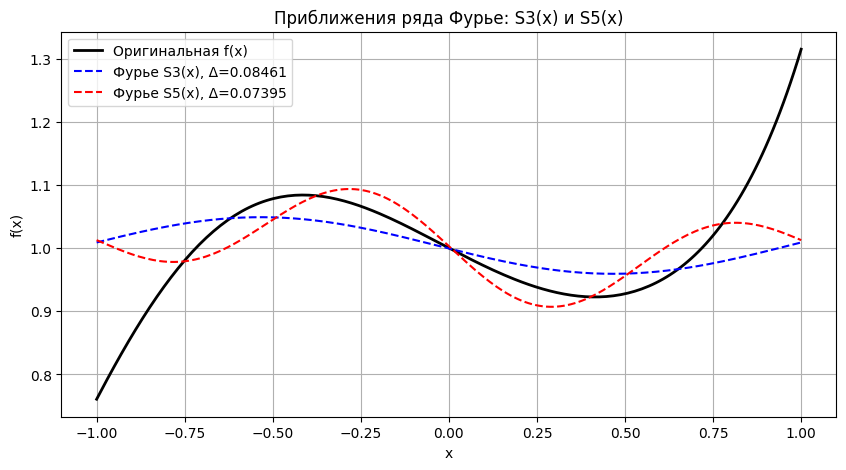

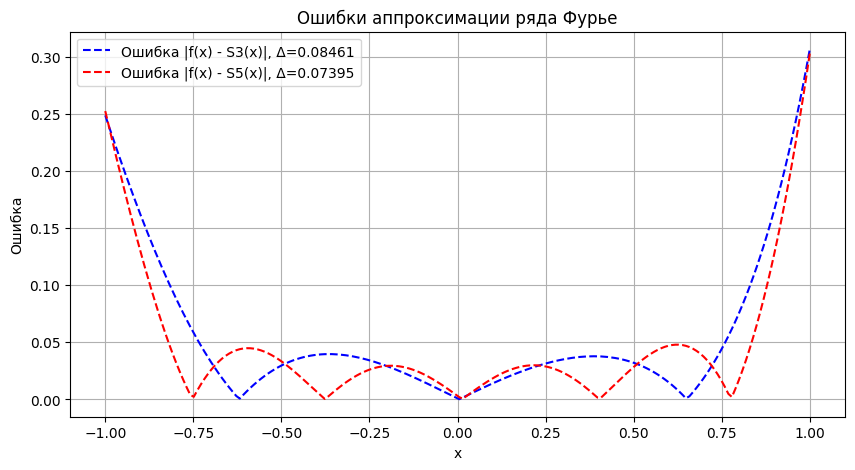

Мера отклонения Δ для S3(x): 0.08461
Мера отклонения Δ для S5(x): 0.07395


,x,f(x),S3(x),S5(x),|f(x) - S3(x)|,|f(x) - S5(x)|
0,-1.000000e+00,0.760332,1.008844,1.012552,0.248512,0.252220
1,-9.000000e-01,0.860868,1.022395,0.990149,0.161527,0.129281
2,-8.000000e-01,0.945358,1.034151,0.978268,0.088794,0.032910
3,-7.000000e-01,1.010315,1.042960,0.984785,0.032646,0.025530
4,-6.000000e-01,1.054371,1.047961,1.009715,0.006410,0.044656
5,-5.000000e-01,1.078154,1.048663,1.044954,0.029491,0.033199
6,-4.000000e-01,1.083911,1.044998,1.077244,0.038914,0.006667
7,-3.000000e-01,1.074997,1.037324,1.093208,0.037673,0.018211
8,-2.000000e-01,1.055350,1.026394,1.084569,0.028956,0.029219
9,-1.000000e-01,1.029048,1.013276,1.051522,0.015772,0.022474


In [7]:
# Вычисляем коэффициенты Фурье методом трапеций
a0 = simpson_rule(lambda x: f(x), N)
a1 = simpson_rule(lambda x: f(x) * np.cos(np.pi * x), N)
b1 = simpson_rule(lambda x: f(x) * np.sin(np.pi * x), N)
a2 = simpson_rule(lambda x: f(x) * np.cos(2 * np.pi * x), N)
b2 = simpson_rule(lambda x: f(x) * np.sin(2 * np.pi * x), N)

# Функции для S3(x) и S5(x)
def S3(x):
    return (a0 / 2) + a1 * np.cos(np.pi * x) + b1 * np.sin(np.pi * x)
def S5(x):
    return S3(x) + a2 * np.cos(2 * np.pi * x) + b2 * np.sin(2 * np.pi * x)

# Генерируем значения x для построения графиков
x_vals = np.linspace(A, B, 200)
f_vals = f(x_vals)
S3_vals = S3(x_vals)
S5_vals = S5(x_vals)

# Вычисляем меру отклонения Δ для S3 и S5
def compute_error(S_vals):
    error_integral = simpson_rule(lambda x: (f(x) - S_vals[np.searchsorted(x_vals, x)])**2, 100)
    return np.sqrt(error_integral / (B - A))

Delta_S3 = compute_error(S3_vals)
Delta_S5 = compute_error(S5_vals)

# График приближений ряда Фурье
fig1, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(x_vals, f_vals, label="Оригинальная f(x)", linewidth=2, color="black")
ax1.plot(x_vals, S3_vals, label=f"Фурье S3(x), Δ={Delta_S3:.5f}", linestyle="dashed", color="blue")
ax1.plot(x_vals, S5_vals, label=f"Фурье S5(x), Δ={Delta_S5:.5f}", linestyle="dashed", color="red")
ax1.legend()
ax1.set_title("Приближения ряда Фурье: S3(x) и S5(x)")
ax1.set_xlabel("x")
ax1.set_ylabel("f(x)")
ax1.grid()
plt.show()

# График ошибки аппроксимации
err_S3 = np.abs(f_vals - S3_vals)
err_S5 = np.abs(f_vals - S5_vals)

fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(x_vals, err_S3, label=f"Ошибка |f(x) - S3(x)|, Δ={Delta_S3:.5f}", linestyle="dashed", color="blue")
ax2.plot(x_vals, err_S5, label=f"Ошибка |f(x) - S5(x)|, Δ={Delta_S5:.5f}", linestyle="dashed", color="red")
ax2.legend()
ax2.set_title("Ошибки аппроксимации ряда Фурье")
ax2.set_xlabel("x")
ax2.set_ylabel("Ошибка")
ax2.grid()
plt.show()

# Таблица значений
x_table = np.arange(A, B + 0.1, 0.1)
df_table = pd.DataFrame({
    "x": x_table,
    "f(x)": f(x_table),
    "S3(x)": S3(x_table),
    "S5(x)": S5(x_table),
    "|f(x) - S3(x)|": np.abs(f(x_table) - S3(x_table)),
    "|f(x) - S5(x)|": np.abs(f(x_table) - S5(x_table))
})

# Отображение таблицы
print(f"Мера отклонения Δ для S3(x): {Delta_S3:.5f}")
print(f"Мера отклонения Δ для S5(x): {Delta_S5:.5f}")
display(df_table)

In [8]:
x_point = 0.8

f_point = f(x_point)
S3_point = S3(x_point)
S5_point = S5(x_point)

err_S3_point = abs(f_point - S3_point)
err_S5_point = abs(f_point - S5_point)

print(f"\nЗначения в контрольной точке x = {x_point}:")
print(f"f({x_point}) = {f_point}")
print(f"S3({x_point}) = {S3_point}")
print(f"S5({x_point}) = {S5_point}")
print(f"Ошибка |f({x_point}) - S3({x_point})| = {err_S3_point}")
print(f"Ошибка |f({x_point}) - S5({x_point})| = {err_S5_point}")


Значения в контрольной точке x = 0.8:
f(0.8) = 1.0578007619867769
S3(0.8) = 0.9817052399552385
S5(0.8) = 1.0398806409689239
Ошибка |f(0.8) - S3(0.8)| = 0.07609552203153835
Ошибка |f(0.8) - S5(0.8)| = 0.017920121017853008


In [9]:
from scipy.interpolate import CubicSpline

# Узлы сплайна (4 промежутка)
x_nodes = np.array([-1, -0.5, 0, 0.5, 1])
y_nodes = f(x_nodes)

# Построение сплайна с естественными граничными условиями
cs = CubicSpline(x_nodes, y_nodes, bc_type='natural')

# Значение в контрольной точке x=0.8
x_test = 0.8
y_true = f(x_test)
y_spline = cs(x_test)
error = abs(y_true - y_spline)

# Вывод результатов
print(f"Значение функции в x=0.8: {y_true:.6f}")
print(f"Значение сплайна в x=0.8: {y_spline:.6f}")
print(f"Ошибка: {error:.6f}")

Значение функции в x=0.8: 1.057801
Значение сплайна в x=0.8: 1.121228
Ошибка: 0.063427


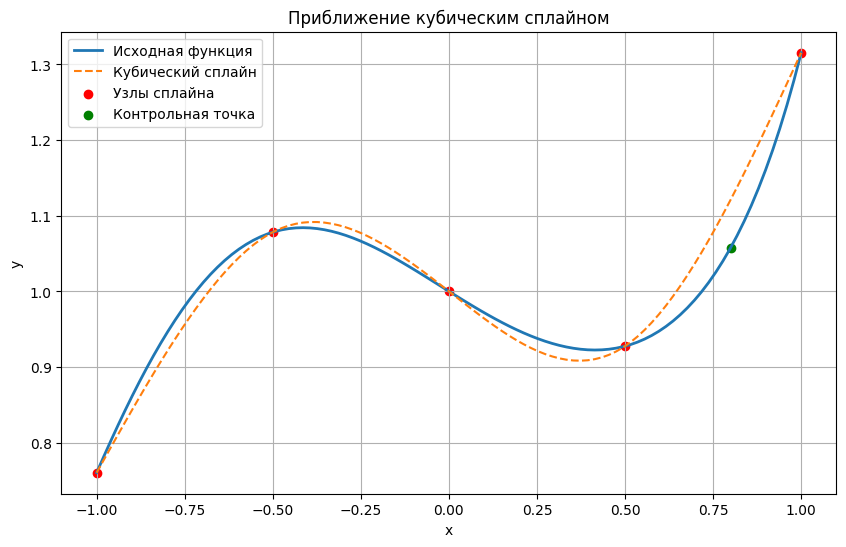

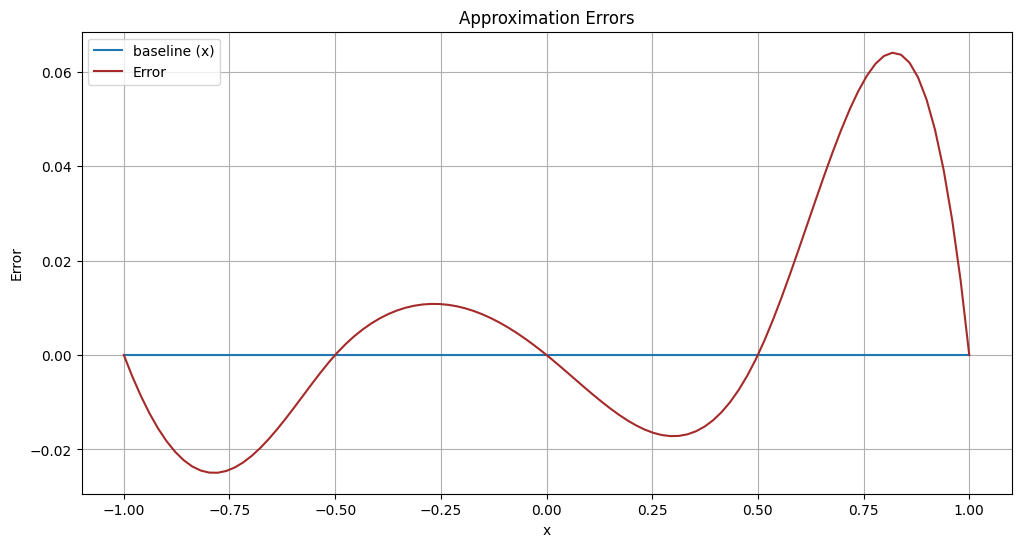

In [10]:
x_vals = np.linspace(-1, 1, 100)
plt.figure(figsize=(10, 6))
plt.plot(x_vals, f(x_vals), label='Исходная функция', linewidth=2)
plt.plot(x_vals, cs(x_vals), '--', label='Кубический сплайн')
plt.scatter(x_nodes, y_nodes, color='red', label='Узлы сплайна')
plt.scatter([x_test], [y_true], color='green', label='Контрольная точка')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Приближение кубическим сплайном')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(x_vals, f(x_vals) - f(x_vals), label='baseline (x)')
plt.plot(x_vals, cs(x_vals) - f(x_vals), label='Error', color='brown')
plt.legend()
plt.xlabel('x')
plt.ylabel('Error')
plt.title('Approximation Errors')
plt.grid(True)
plt.show()

In [11]:
x_vals = np.linspace(-1, 1, 100)
y_true = f(x_vals)

# Точечное приближение (6 точек)
points_x = np.array([-1, -0.6, -0.2, 0.2, 0.6, 1])
points_y = f(points_x)

# Построение матрицы для МНК
A = np.vstack([np.ones_like(points_x), points_x, points_x**2]).T
c_point, residuals, _, _ = np.linalg.lstsq(A, points_y, rcond=None)
print("Коэффициенты точечного приближения:", c_point)

# Точечное приближение
y_point = c_point[0] + c_point[1] * x_vals + c_point[2] * x_vals**2
mse_point = np.mean((y_true - y_point)**2)

print(f"MSE точечного приближения: {mse_point:.4f}")

Коэффициенты точечного приближения: [0.99461938 0.16777179 0.04054901]
MSE точечного приближения: 0.0123


In [12]:
from scipy.integrate import quad
from scipy.linalg import solve

# Интегральное приближение
def integrand(x, power):
    return x**power * f(x)

# Вычисление интегралов
int_f = quad(f, -1, 1)[0]
int_xf = quad(lambda x: x * f(x), -1, 1)[0]
int_x2f = quad(lambda x: x**2 * f(x), -1, 1)[0]

# Матрица системы для интегрального метода
matrix = np.array([
    [2, 0, 2/3],
    [0, 2/3, 0],
    [2/3, 0, 2/5]
])
rhs = np.array([int_f, int_xf, int_x2f])
c_integral = solve(matrix, rhs)
print("Коэффициенты интегрального приближения:", c_integral)

# Интегральное приближение
y_integral = c_integral[0] + c_integral[1] * x_vals + c_integral[2] * x_vals**2
mse_integral = np.mean((y_true - y_integral)**2)

print(f"MSE интегрального приближения: {mse_integral:.4f}")

Коэффициенты интегрального приближения: [0.99889959 0.04810413 0.0154494 ]
MSE интегрального приближения: 0.0079


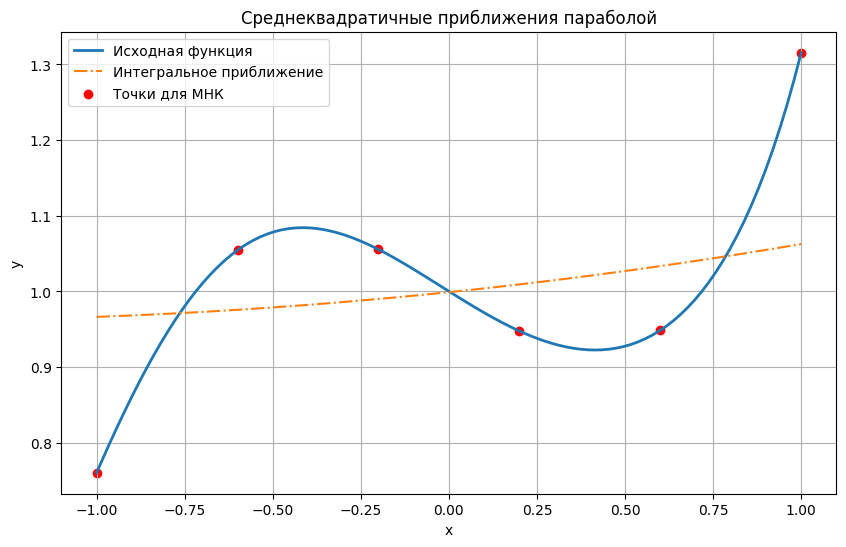

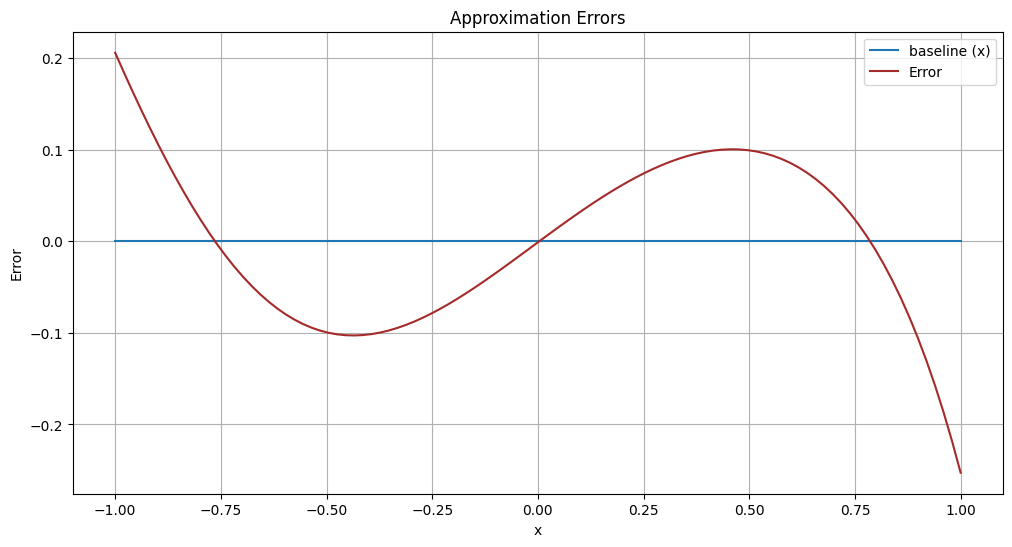

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_true, label='Исходная функция', linewidth=2)
plt.plot(x_vals, y_integral, '-.', label='Интегральное приближение')
plt.scatter(points_x, points_y, color='red', label='Точки для МНК')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Среднеквадратичные приближения параболой')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(x_vals, y_true - y_true, label='baseline (x)')
plt.plot(x_vals, y_integral - y_true, label='Error', color='brown')
plt.legend()
plt.xlabel('x')
plt.ylabel('Error')
plt.title('Approximation Errors')
plt.grid(True)
plt.show()